# CQSFA-only amplitude, per orbit

Plots CQSFA_fwd's own `Amplitude_Grid` output for the source-restricted (100%-pure)
`orbit1only_better`, `orbit2only_better`, and `orbit12only_better` (combined) runs.

For each run, three quantities are compared side by side:
- **bare $|M|^2$** (col 5): unweighted coherent sum, no prefactor - shows chaotic
  caustic-driven noise within a single orbit type.
- **physical $|M_{pref}|^2$** (col 8): full CQSFA prefactor (stability factor +
  matrix element + sub-barrier Coulomb correction + multi-cycle ATI-comb modulation)
  - the correct physical result, shows genuine ATI-ring interference.
- **$|M_{qpref}|^2$** (col 11): stability-factor-only prefactor, with the ATI-comb
  modulation (and Coulomb correction/matrix element) omitted - the smooth "single
  optical cycle" envelope without the multi-cycle ATI-ring quantization.

Set `SELECTED_RUN` in the switch cell to `"orbit1"`, `"orbit2"`, or `"orbit12"` and
re-run that cell to flip between them, or run the final cell to see all three at once.


In [31]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# All runs share the same 500x500x1 final-momentum grid (Frankenstein_He_electron2, "better" family)
RUNS = {
    "orbit1": dict(
        dir="/workspaces/CQSFA/CQSFA_fwd/runs/Frankenstein_He_electron2_orbit1only_better",
        tag="orbit1only_better",
        grid="500X500X1",
        label="orbit 1 only",
    ),
    "orbit2": dict(
        dir="/workspaces/CQSFA/CQSFA_fwd/runs/Frankenstein_He_electron2_orbit2only_better",
        tag="orbit2only_better",
        grid="500X500X1",
        label="orbit 2 only",
    ),
    "orbit3": dict(
        dir="/workspaces/CQSFA/CQSFA_fwd/runs/Frankenstein_He_electron2_orbit3only_better",
        tag="orbit3only_better",
        grid="500X500X1",
        label="orbit 3 only",
    ),
    "orbit4": dict(
        dir="/workspaces/CQSFA/CQSFA_fwd/runs/Frankenstein_He_electron2_orbit4only_better",
        tag="orbit4only_better",
        grid="500X500X1",
        label="orbit 4 only",
    ),
    "orbit12": dict(
        dir="/workspaces/CQSFA/CQSFA_fwd/runs/Frankenstein_He_electron2_orbit12only_better",
        tag="orbit12only_better",
        grid="500X500X1",
        label="orbits 1+2 combined",
    ),
    "orbit1234": dict(
        dir="/workspaces/CQSFA/CQSFA_fwd/runs/Frankenstein_He_electron2_orbit1234only_better",
        tag="orbit1234only_better",
        grid="500X500X1",
        label="orbits 1+2+3+4 combined",
    ),
}
Nz = Ny = 500


In [28]:
def load_amplitude(run_key):
    r = RUNS[run_key]
    path = f"{r['dir']}/Data/Amplitude_Grid_Frankenstein_He_electron2_{r['tag']}_{r['grid']}.dat"
    amp_data = np.loadtxt(path)
    pz = amp_data[:, 0].reshape(Nz, Ny)[:, 0]
    py = amp_data[:, 1].reshape(Nz, Ny)[0, :]
    quantities = {
        "bare $|M|^2$ (no prefactor)": np.abs(amp_data[:, 5]).reshape(Nz, Ny),
        "physical $|M_{pref}|^2$ (full prefactor)": np.abs(amp_data[:, 8]).reshape(Nz, Ny),
        "$|M_{qpref}|^2$ (no ATI-comb/Coulomb-corr.)": np.abs(amp_data[:, 11]).reshape(Nz, Ny),
    }
    return pz, py, quantities


def plot_run(run_key):
    pz, py, quantities = load_amplitude(run_key)
    label = RUNS[run_key]["label"]
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    for ax, (title, d) in zip(axes, quantities.items()):
        mask = d > 0
        vmax = np.percentile(d[mask], 99.5) if mask.any() else 1.0
        pcm = ax.pcolormesh(pz, py, d.T, norm=LogNorm(vmin=vmax * 1e-6, vmax=vmax), shading="auto", cmap="jet")
        ax.set_xlabel(r"$p_{2,long}$ (a.u.)"); ax.set_ylabel(r"$p_{2,trans}$ (a.u.)")
        ax.set_title(f"{label}: {title}", fontsize=9)
        fig.colorbar(pcm, ax=ax)
    plt.tight_layout()
    plt.show()


## Switch between runs

Change `SELECTED_RUN` below to `"orbit1"`, `"orbit2"`, or `"orbit12"` and re-run this cell.


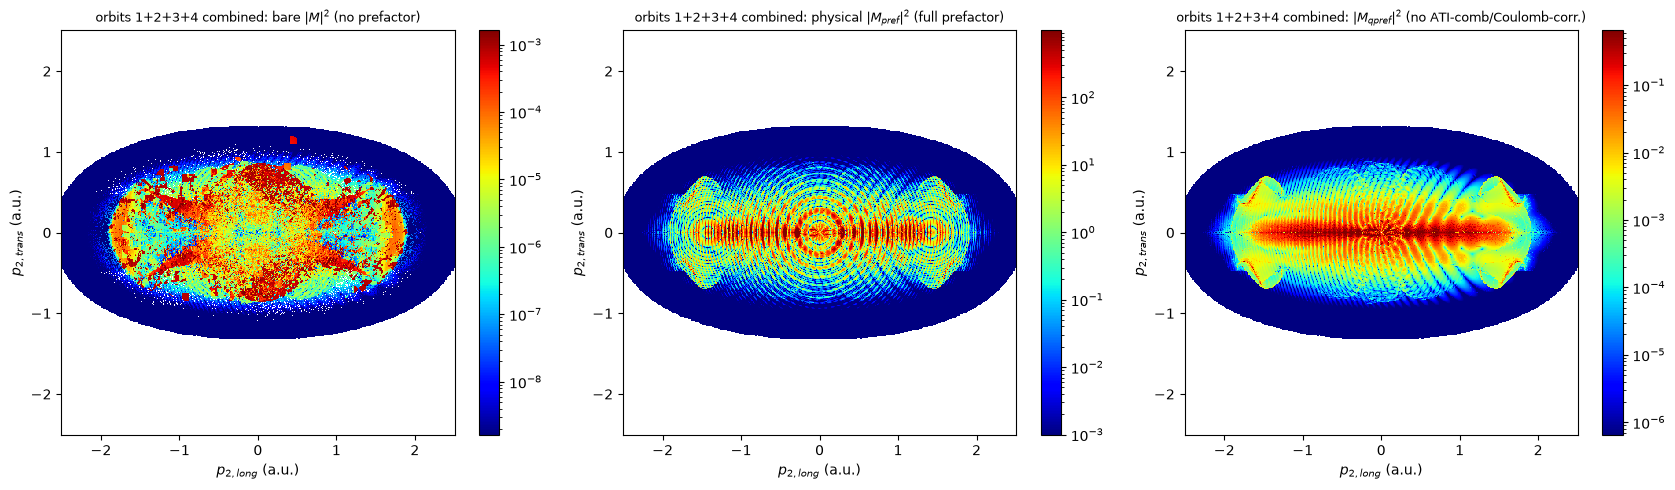

In [32]:
SELECTED_RUN = "orbit1234"  # "orbit1", "orbit2", "orbit3", "orbit4", "orbit12", or "orbit1234"
plot_run(SELECTED_RUN)


## All three runs side by side

Rows: orbit 1, orbit 2, orbits 1+2 combined. Columns: bare, physical (full prefactor), qPref (no ATI-comb).


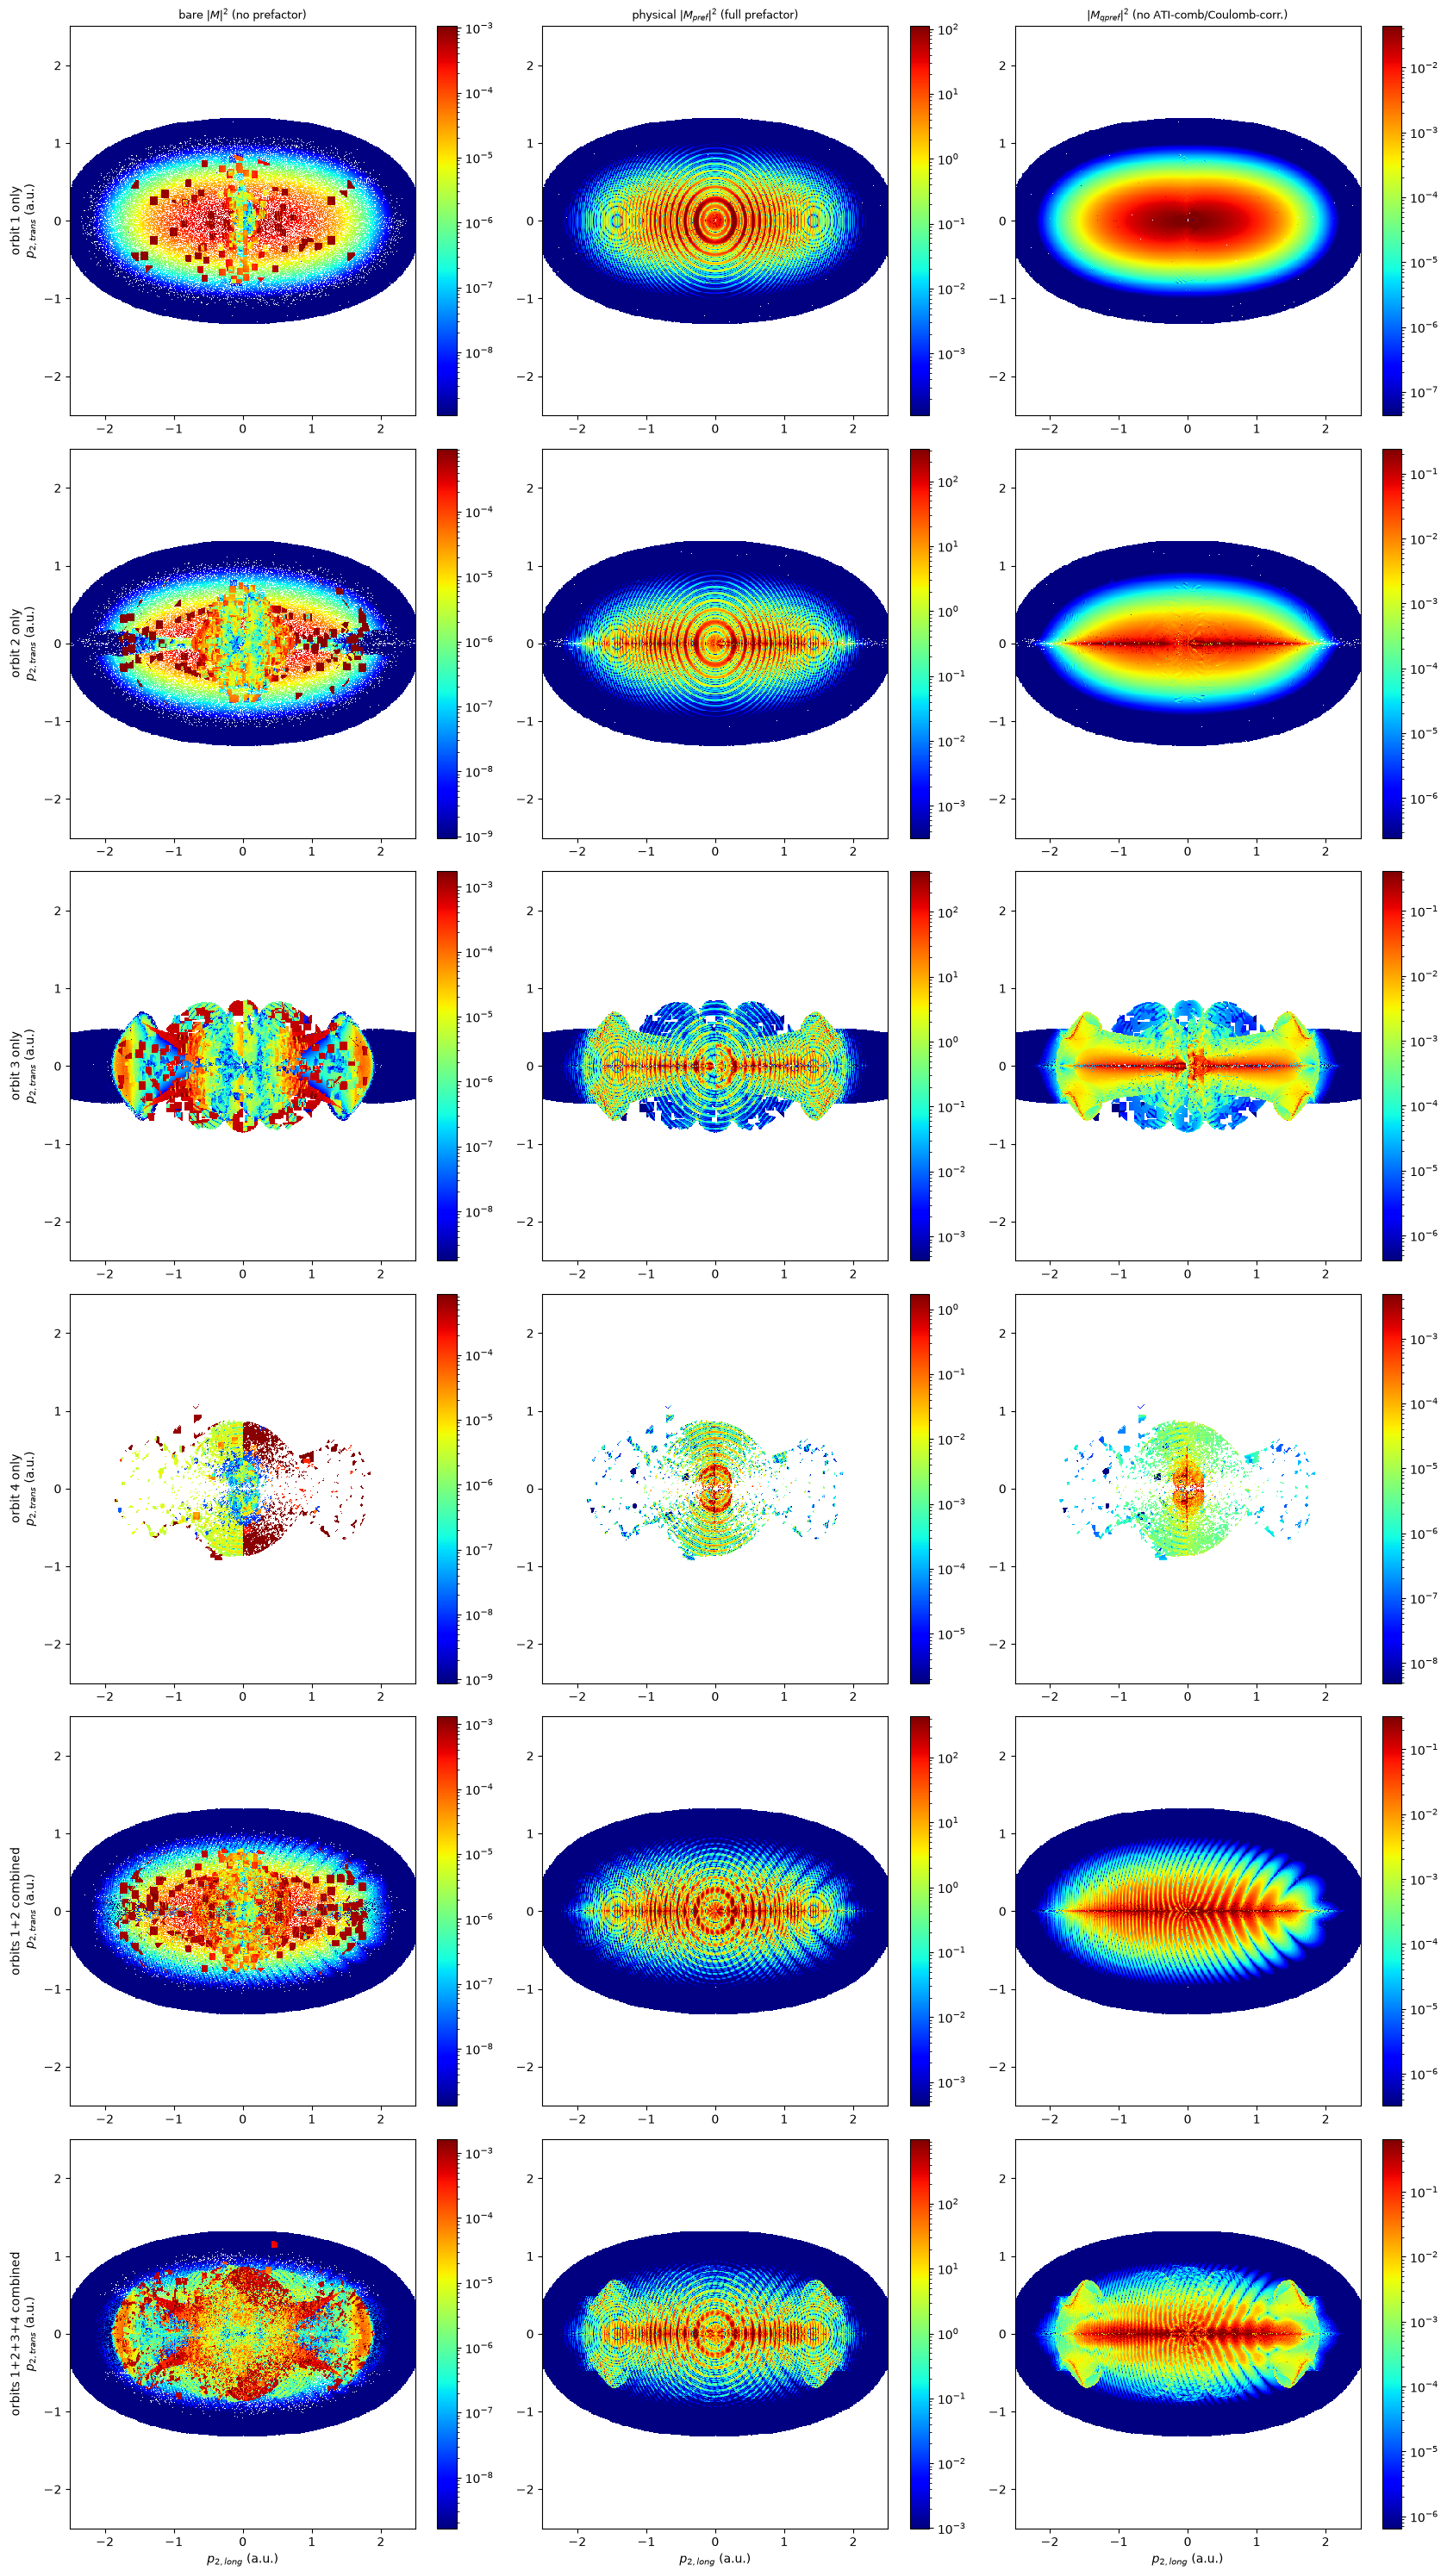

In [33]:
fig, axes = plt.subplots(len(RUNS), 3, figsize=(17, 5 * len(RUNS)))
for row, run_key in enumerate(RUNS):
    pz, py, quantities = load_amplitude(run_key)
    label = RUNS[run_key]["label"]
    for col, (title, d) in enumerate(quantities.items()):
        ax = axes[row, col]
        mask = d > 0
        vmax = np.percentile(d[mask], 99.5) if mask.any() else 1.0
        pcm = ax.pcolormesh(pz, py, d.T, norm=LogNorm(vmin=vmax * 1e-6, vmax=vmax), shading="auto", cmap="jet")
        if row == len(RUNS) - 1:
            ax.set_xlabel(r"$p_{2,long}$ (a.u.)")
        ax.set_ylabel(f"{label}\n" + r"$p_{2,trans}$ (a.u.)" if col == 0 else "")
        if row == 0:
            ax.set_title(title, fontsize=9)
        fig.colorbar(pcm, ax=ax)
plt.tight_layout()
plt.show()
